In [1]:
!pip install datasets einops diffusers openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 137.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 662.0/662.0 kB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 111.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: dill
    Found existing installation: dill 0.4.0
    Uninstalling dill-0.4.0:
      Successfully uninstalled dill-0.4.0
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.18
    Uninstalling multiprocess-0.70.18:
      Successfully uninstalled multiprocess-0.70.18
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pathos 0.3.4 requires dill>=0.4.0, but you have dill 0.3.8 which is incompatible.
pathos 0.3.4 requir

In [1]:
import os
from PIL import Image
import torch
import numpy as np
from torchvision import utils
import matplotlib.pyplot as plt

from torch.utils.data import Dataset

from torchvision.transforms import (CenterCrop,
    Compose,InterpolationMode,RandomHorizontalFlip,
    Resize,ToTensor)

resolution=64

In [2]:
augmentations = Compose([
    Resize(resolution, 
    interpolation=InterpolationMode.BILINEAR),
    CenterCrop(resolution),
    RandomHorizontalFlip(),
    ToTensor(),])

def transforms(examples):
    images = [augmentations(image.convert("RGB"))
        for image in examples["image"]]
    return {"input": images}

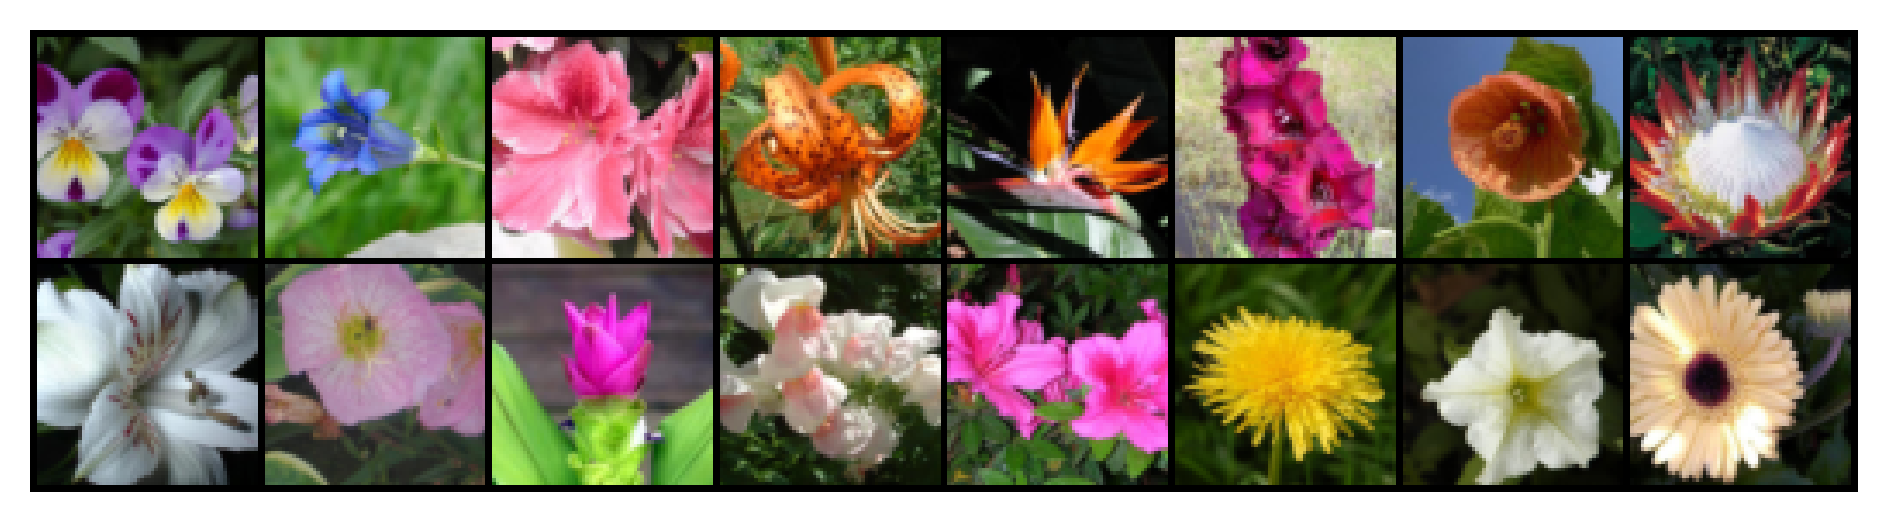

In [3]:
from datasets import load_dataset
#from utils.ch15util import transforms

ds = load_dataset("huggan/flowers-102-categories",
    split="train",)
ds.set_transform(transforms)

import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# Plot all the images of the 1st batch in grid
grid = make_grid(ds[:16]["input"], 8, 2)
plt.figure(figsize=(8,2),dpi=300)
plt.imshow(grid.numpy().transpose((1,2,0)))
plt.axis("off")
plt.show()

In [4]:
ds

Dataset({
    features: ['image'],
    num_rows: 8189
})

In [5]:
#ds['image'][0]

In [6]:
import torch

import matplotlib.pyplot as plt
from torchvision.utils import make_grid
resolution=64
batch_size=4
train_dataloader=torch.utils.data.DataLoader(
    ds, batch_size=batch_size, shuffle=True)


In [7]:
clean_images=next(iter(train_dataloader))["input"]*2-1
print(clean_images.shape)
nums=clean_images.shape[0]
noise=torch.randn(clean_images.shape)
print(noise.shape)

torch.Size([4, 3, 64, 64])
torch.Size([4, 3, 64, 64])


In [12]:
class CustomDataset(Dataset):

    def __init__(self, data_df, transforms):
        image_paths = []
        for idx, row in data_df.iterrows():
            image_path = row["image_path"]

            image_paths.append(image_path)
        self.image_paths = image_paths
        self.transforms = transforms

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")
        image = self.transforms(image)
        return {"input": image}


def plot_losses(losses, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    plt.plot(losses, label='train')
    plt.legend()
    plt.savefig(f"{out_dir}/losses.png")
    plt.clf()


def save_images(generated_images, epoch, batch_size):
    images = generated_images["sample"]
    images_processed = (images * 255).round().astype("uint8")
    out_dir = f"./{epoch}/"
    os.makedirs(out_dir)
    for idx, image in enumerate(images_processed):
        image = Image.fromarray(image)
        image.save(f"{out_dir}/{epoch}_{idx}.jpeg")
    utils.save_image(generated_images["sample_pt"],
                        f"{out_dir}/{epoch}_grid.jpeg",
                        nrow=batch_size // 4)


def normalize_to_neg_one_to_one(img):
    return img * 2 - 1


def unnormalize_to_zero_to_one(t):
    return (t + 1) * 0.5


def numpy_to_pil(images):
    if images.ndim == 3:
        images = images[None, ...]
    images = (images * 255).round().astype("uint8")
    pil_images = [Image.fromarray(image) for image in images]

    return pil_images


def match_shape(values, broadcast_array, tensor_format="pt"):
    values = values.flatten()

    while len(values.shape) < len(broadcast_array.shape):
        values = values[..., None]
    if tensor_format == "pt":
        values = values.to(broadcast_array.device)

    return values


def clip(tensor, min_value=None, max_value=None):
    if isinstance(tensor, np.ndarray):
        return np.clip(tensor, min_value, max_value)
    elif isinstance(tensor, torch.Tensor):
        return torch.clamp(tensor, min_value, max_value)

    raise ValueError("Tensor format is not valid is not valid - " \
        f"should be numpy array or torch tensor. Got {type(tensor)}.")
        
        
        
        
        
        
# attention related 
from torch import nn, einsum
import torch.nn.functional as F

from einops import rearrange


class LayerNorm(nn.Module):

    def __init__(self, dim):
        super().__init__()
        self.g = nn.Parameter(torch.ones(1, dim, 1, 1))

    def forward(self, x):
        eps = 1e-5 if x.dtype == torch.float32 else 1e-3
        var = torch.var(x, dim=1, unbiased=False, keepdim=True)
        mean = torch.mean(x, dim=1, keepdim=True)
        return (x - mean) * (var + eps).rsqrt() * self.g


class Attention(nn.Module):

    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head**-0.5
        self.heads = heads
        hidden_dim = dim_head * heads

        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out = nn.Conv2d(hidden_dim, dim, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(
            lambda t: rearrange(t, 'b (h c) x y -> b h c (x y)', h=self.heads),
            qkv)

        q = q * self.scale

        sim = einsum('b h d i, b h d j -> b h i j', q, k)
        attn = sim.softmax(dim=-1)
        out = einsum('b h i j, b h d j -> b h i d', attn, v)

        out = rearrange(out, 'b h (x y) d -> b (h d) x y', x=h, y=w)
        return self.to_out(out)       
        
        
        

# adapted from https://github.com/huggingface/diffusers/blob/main/src/diffusers/schedulers/scheduling_ddim.py
# adapted from https://github.com/filipbasara0/simple-diffusion
import math
from typing import Union

import numpy as np
import torch
from tqdm import tqdm



def cosine_beta_schedule(timesteps, beta_start=0.0, beta_end=0.999, s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps, dtype=torch.float32)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5)**2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, beta_start, beta_end)


class DDIMScheduler:

    def __init__(
        self,
        num_train_timesteps=1000,
        beta_start=0.0001,
        beta_end=0.02,
        beta_schedule="cosine",
        clip_sample=True,
        set_alpha_to_one=True
    ):

        if beta_schedule == "linear":
            self.betas = np.linspace(beta_start, beta_end, num_train_timesteps, dtype=np.float32)
        elif beta_schedule == "cosine":
            self.betas = cosine_beta_schedule(num_train_timesteps,
                                              beta_start=beta_start,
                                              beta_end=beta_end)
        else:
            raise NotImplementedError(
                f"{beta_schedule} does is not implemented for {self.__class__}")

        self.num_train_timesteps = num_train_timesteps
        self.clip_sample = clip_sample
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = np.cumprod(self.alphas, axis=0)

        self.final_alpha_cumprod = np.array(1.0) if set_alpha_to_one else self.alphas_cumprod[0]

        self.num_inference_steps = None
        self.timesteps = np.arange(0, num_train_timesteps)[::-1].copy()

    def _get_variance(self, timestep, prev_timestep):
        alpha_prod_t = self.alphas_cumprod[timestep]
        alpha_prod_t_prev = self.alphas_cumprod[
            prev_timestep] if prev_timestep >= 0 else self.final_alpha_cumprod
        beta_prod_t = 1 - alpha_prod_t
        beta_prod_t_prev = 1 - alpha_prod_t_prev

        variance = (beta_prod_t_prev / beta_prod_t) * (1 - alpha_prod_t / alpha_prod_t_prev)

        return variance

    def set_timesteps(self, num_inference_steps, offset=0):
        self.num_inference_steps = num_inference_steps
        self.timesteps = np.arange(0, 1000, 1000 // num_inference_steps)[::-1].copy()
        self.timesteps += offset

    def step(
        self,
        model_output: Union[torch.FloatTensor, np.ndarray],
        timestep: int,
        sample: Union[torch.FloatTensor, np.ndarray],
        eta: float = 1.0,
        use_clipped_model_output: bool = True,
        generator=None,
    ):

        prev_timestep = timestep - self.num_train_timesteps // self.num_inference_steps

        alpha_prod_t = self.alphas_cumprod[timestep]
        alpha_prod_t_prev = self.alphas_cumprod[
            prev_timestep] if prev_timestep >= 0 else self.final_alpha_cumprod
        beta_prod_t = 1 - alpha_prod_t

        pred_original_sample = (sample - beta_prod_t**(0.5) * model_output) / alpha_prod_t**(0.5)

        if self.clip_sample:
            pred_original_sample = clip(pred_original_sample, -1, 1)


        variance = self._get_variance(timestep, prev_timestep)
        std_dev_t = eta * variance**(0.5)

        if use_clipped_model_output:
            model_output = (sample -
                            alpha_prod_t**(0.5) * pred_original_sample) / beta_prod_t**(0.5)

        pred_sample_direction = (1 - alpha_prod_t_prev - std_dev_t**2)**(0.5) * model_output

        prev_sample = alpha_prod_t_prev**(0.5) * pred_original_sample + pred_sample_direction

        if eta > 0:
            device = model_output.device if torch.is_tensor(model_output) else "cpu"
            noise = torch.randn(model_output.shape, generator=generator).to(device)
            variance = self._get_variance(timestep, prev_timestep)**(0.5) * eta * noise

            if not torch.is_tensor(model_output):
                variance = variance.numpy()

            prev_sample = prev_sample + variance

        return prev_sample

    def add_noise(self, original_samples, noise, timesteps):
        timesteps = timesteps.cpu()
        sqrt_alpha_prod = self.alphas_cumprod[timesteps]**0.5
        sqrt_alpha_prod = match_shape(sqrt_alpha_prod, original_samples)
        sqrt_one_minus_alpha_prod = (1 - self.alphas_cumprod[timesteps])**0.5
        sqrt_one_minus_alpha_prod = match_shape(sqrt_one_minus_alpha_prod, original_samples)

        noisy_samples = sqrt_alpha_prod * original_samples + sqrt_one_minus_alpha_prod * noise
        return noisy_samples

    @torch.no_grad()
    def generate(self,model,device,batch_size=1,generator=None,
         eta=1.0,use_clipped_model_output=True,num_inference_steps=50):
        imgs=[]
        image=torch.randn((batch_size,model.in_channels,model.sample_size,
            model.sample_size),generator=generator).to(device)
        self.set_timesteps(num_inference_steps)
        for t in tqdm(self.timesteps):
            model_output = model(image, t)["sample"]
            image = self.step(model_output,t,image,eta,
                  use_clipped_model_output=use_clipped_model_output)
            img = unnormalize_to_zero_to_one(image)
            img = img.cpu().permute(0, 2, 3, 1).numpy()
            imgs.append(img)
        image = unnormalize_to_zero_to_one(image)
        image = image.cpu().permute(0, 2, 3, 1).numpy()
        return {"sample": image}, imgs
    def __len__(self):
        return self.num_train_timesteps

In [15]:
import math
import torch
from torch import nn
from torch.nn import functional as F
from einops.layers.torch import Rearrange

#from utils.ch14util import Attention, LayerNorm


def get_downsample_layer(in_dim, hidden_dim, is_last):
    if not is_last:
        return nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (c p1 p2) h w', p1=2, p2=2),
            nn.Conv2d(in_dim * 4, hidden_dim, 1))
    else:
        return nn.Conv2d(in_dim, hidden_dim, 3, padding=1)


def get_attn_layer(in_dim, is_last):
    if is_last:
        return Residual(PreNorm(in_dim, Attention(in_dim)))
    else:
        return nn.Identity()


def get_upsample_layer(in_dim, hidden_dim, is_last):
    if not is_last:
        return nn.Sequential(nn.Upsample(scale_factor=2, mode='nearest'),
                             nn.Conv2d(in_dim, hidden_dim, 3, padding=1))
    else:
        return nn.Conv2d(in_dim, hidden_dim, 3, padding=1)


def sinusoidal_embedding(timesteps, dim):
    half_dim = dim // 2
    exponent = -math.log(10000) * torch.arange(
        start=0, end=half_dim, dtype=torch.float32)
    exponent = exponent / (half_dim - 1.0)

    emb = torch.exp(exponent).to(device=timesteps.device)
    emb = timesteps[:, None].float() * emb[None, :]

    return torch.cat([emb.sin(), emb.cos()], dim=-1)


class Residual(nn.Module):

    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, *args, **kwargs):
        return self.fn(x, *args, **kwargs) + x


class PreNorm(nn.Module):

    def __init__(self, dim, fn):
        super().__init__()
        self.fn = fn
        self.norm = LayerNorm(dim)

    def forward(self, x):
        x = self.norm(x)
        return self.fn(x)


class ResidualBlock(nn.Module):

    def __init__(self,
                 in_channels,
                 out_channels,
                 temb_channels,
                 kernel_size=3,
                 stride=1,
                 padding=1,
                 groups=8):
        super(ResidualBlock, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels

        self.time_emb_proj = nn.Sequential(
            nn.SiLU(), torch.nn.Linear(temb_channels, out_channels))

        self.residual_conv = nn.Conv2d(
            in_channels, out_channels=out_channels,
            kernel_size=1) if in_channels != out_channels else nn.Identity()

        self.conv1 = nn.Conv2d(in_channels,
                               out_channels=out_channels,
                               kernel_size=kernel_size,
                               stride=stride,
                               padding=padding)
        self.conv2 = nn.Conv2d(out_channels,
                               out_channels=out_channels,
                               kernel_size=kernel_size,
                               stride=stride,
                               padding=padding)

        self.norm1 = nn.GroupNorm(num_channels=out_channels, num_groups=groups)
        self.norm2 = nn.GroupNorm(num_channels=out_channels, num_groups=groups)
        self.nonlinearity = nn.SiLU()

    def forward(self, x, temb):
        residual = self.residual_conv(x)

        x = self.conv1(x)
        x = self.norm1(x)
        x = self.nonlinearity(x)

        temb = self.time_emb_proj(self.nonlinearity(temb))
        x += temb[:, :, None, None]

        x = self.conv2(x)
        x = self.norm2(x)
        x = self.nonlinearity(x)

        return x + residual


class UNet(nn.Module):

    def __init__(self,
                 in_channels,
                 hidden_dims=[128, 256, 512, 1024],
                 image_size=64):
        super(UNet, self).__init__()

        self.sample_size = image_size
        self.in_channels = in_channels
        self.hidden_dims = hidden_dims

        timestep_input_dim = hidden_dims[0]
        time_embed_dim = timestep_input_dim * 4

        self.time_embedding = nn.Sequential(
            nn.Linear(timestep_input_dim, time_embed_dim), nn.SiLU(),
            nn.Linear(time_embed_dim, time_embed_dim))

        self.init_conv = nn.Conv2d(in_channels,
                                   out_channels=hidden_dims[0],
                                   kernel_size=3,
                                   stride=1,
                                   padding=1)

        down_blocks = []

        in_dim = hidden_dims[0]
        for idx, hidden_dim in enumerate(hidden_dims[1:]):
            is_last = idx >= (len(hidden_dims) - 2)
            down_blocks.append(
                nn.ModuleList([
                    ResidualBlock(in_dim, in_dim, time_embed_dim),
                    ResidualBlock(in_dim, in_dim, time_embed_dim),
                    get_attn_layer(in_dim, is_last),
                    get_downsample_layer(in_dim, hidden_dim, is_last)
                ]))
            in_dim = hidden_dim

        self.down_blocks = nn.ModuleList(down_blocks)

        mid_dim = hidden_dims[-1]
        self.mid_block1 = ResidualBlock(mid_dim, mid_dim, time_embed_dim)
        self.mid_attn = Residual(PreNorm(mid_dim, Attention(mid_dim)))
        self.mid_block2 = ResidualBlock(mid_dim, mid_dim, time_embed_dim)

        up_blocks = []
        in_dim = mid_dim
        for idx, hidden_dim in enumerate(list(reversed(hidden_dims[:-1]))):
            is_last = idx >= (len(hidden_dims) - 2)
            up_blocks.append(
                nn.ModuleList([
                    ResidualBlock(in_dim + hidden_dim, in_dim, time_embed_dim),
                    ResidualBlock(in_dim + hidden_dim, in_dim, time_embed_dim),
                    get_attn_layer(in_dim, is_last),
                    get_upsample_layer(in_dim, hidden_dim, is_last)
                ]))
            in_dim = hidden_dim

        self.up_blocks = nn.ModuleList(up_blocks)

        self.out_block = ResidualBlock(hidden_dims[0] * 2, hidden_dims[0],
                                       time_embed_dim)
        self.conv_out = nn.Conv2d(hidden_dims[0], out_channels=3, kernel_size=1)

    def forward(self, sample, timesteps):
        if not torch.is_tensor(timesteps):
            timesteps = torch.tensor([timesteps],
                                     dtype=torch.long,
                                     device=sample.device)

        timesteps = torch.flatten(timesteps)
        timesteps = timesteps.broadcast_to(sample.shape[0])

        t_emb = sinusoidal_embedding(timesteps, self.hidden_dims[0])
        t_emb = self.time_embedding(t_emb)

        x = self.init_conv(sample)
        r = x.clone()

        skips = []
        for block1, block2, attn, downsample in self.down_blocks:
            x = block1(x, t_emb)
            skips.append(x)

            x = block2(x, t_emb)
            x = attn(x)
            skips.append(x)

            x = downsample(x)

        x = self.mid_block1(x, t_emb)
        x = self.mid_attn(x)
        x = self.mid_block2(x, t_emb)

        for block1, block2, attn, upsample in self.up_blocks:
            x = torch.cat((x, skips.pop()), dim=1)
            x = block1(x, t_emb)

            x = torch.cat((x, skips.pop()), dim=1)
            x = block2(x, t_emb)
            x = attn(x)

            x = upsample(x)

        x = self.out_block(torch.cat((x, r), dim=1), t_emb)
        out = self.conv_out(x)
        return {"sample": out}

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5746694..2.6436207].


tensor([199, 199, 199, 199])
tensor([399, 399, 399, 399])
tensor([599, 599, 599, 599])
tensor([799, 799, 799, 799])
tensor([999, 999, 999, 999])


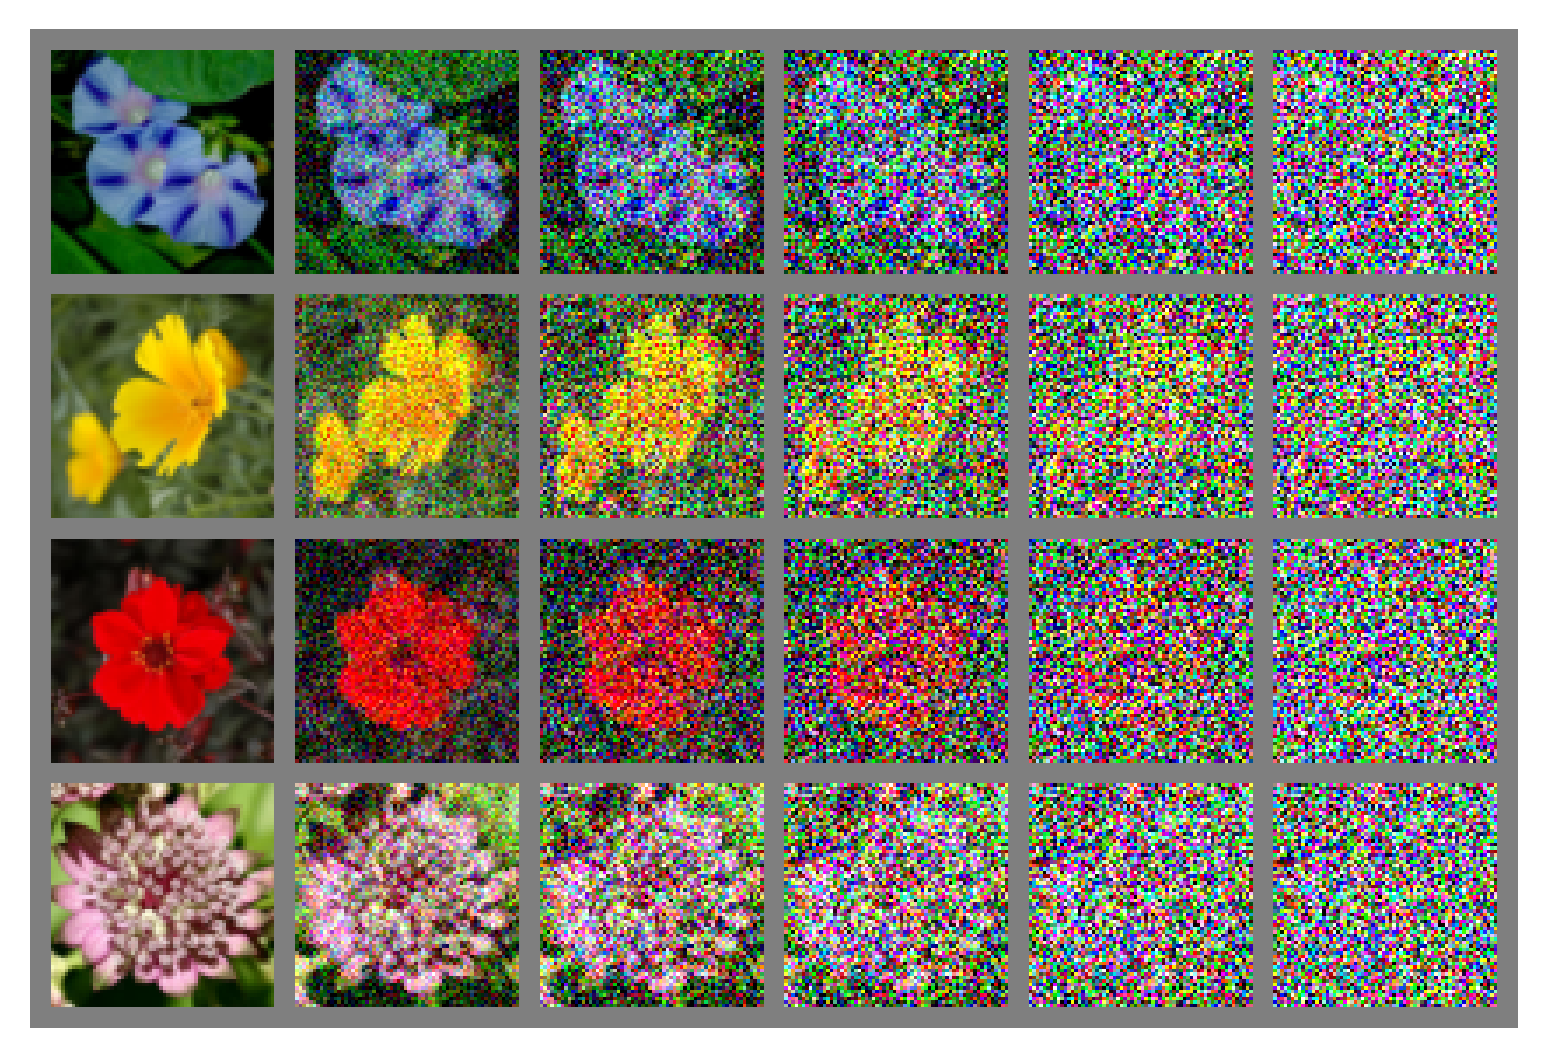

In [16]:
noise_scheduler=DDIMScheduler(num_train_timesteps=1000)
allimgs=clean_images
for step in range(200,1001,200):
    timesteps=torch.tensor([step-1]*4).long()
    print(timesteps)
    noisy_images=noise_scheduler.add_noise(clean_images,
                 noise, timesteps)
    allimgs=torch.cat((allimgs,noisy_images))

import torchvision
imgs=torchvision.utils.make_grid(allimgs,4,6)
fig = plt.figure(dpi=300)
plt.imshow((imgs.permute(2,1,0)+1)/2)
plt.axis("off")
plt.show()

In [17]:
import torch
from torch import nn, einsum
from einops import rearrange

class Attention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head**-0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out = nn.Conv2d(hidden_dim, dim, 1)
    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)    #A
        q, k, v = map(
        lambda t: rearrange(t, 'b (h c) x y -> b h c (x y)', h=self.heads),
        qkv)    #B
        q = q * self.scale    
        sim = einsum('b h d i, b h d j -> b h i j', q, k)
        attn = sim.softmax(dim=-1)    #C
        out = einsum('b h i j, b h d j -> b h i d', attn, v)    #D
        out = rearrange(out, 'b h (x y) d -> b (h d) x y', x=h, y=w)
        return self.to_out(out)    #E
attn=Attention(128)
x=torch.rand(1,128,64,64)
out=attn(x)
print(out.shape)

torch.Size([1, 128, 64, 64])


In [18]:
device="cuda" if torch.cuda.is_available() else "cpu"
resolution=64
model=UNet(3,hidden_dims=[128,256,512,1024],
           image_size=resolution).to(device)
num=sum(p.numel() for p in model.parameters())
print("number of parameters: %.2fM" % (num/1e6,))
print(model)

number of parameters: 133.42M
UNet(
  (time_embedding): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): SiLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
  )
  (init_conv): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (down_blocks): ModuleList(
    (0): ModuleList(
      (0-1): 2 x ResidualBlock(
        (time_emb_proj): Sequential(
          (0): SiLU()
          (1): Linear(in_features=512, out_features=128, bias=True)
        )
        (residual_conv): Identity()
        (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm1): GroupNorm(8, 128, eps=1e-05, affine=True)
        (norm2): GroupNorm(8, 128, eps=1e-05, affine=True)
        (nonlinearity): SiLU()
      )
      (2): Identity()
      (3): Sequential(
        (0): Rearrange('b c (h p1) (w p2) -> b (c p1 p2) h w', p1=2, p2=2)
     

In [19]:
from diffusers.optimization import get_scheduler

num_epochs=100
optimizer=torch.optim.AdamW(model.parameters(),lr=0.0001,
    betas=(0.95,0.999),weight_decay=0.00001,eps=1e-8)
lr_scheduler=get_scheduler(
    "cosine",
    optimizer=optimizer,
    num_warmup_steps=300,
    num_training_steps=(len(train_dataloader) * num_epochs))

In [ ]:
for epoch in range(num_epochs):
    model.train()
    tloss = 0
    print(f"start epoch {epoch}")
    for step, batch in enumerate(train_dataloader):
        clean_images = batch["input"].to(device)*2-1
        nums = clean_images.shape[0]
        noise = torch.randn(clean_images.shape).to(device)
        timesteps = torch.randint(0,
                noise_scheduler.num_train_timesteps,
                (nums, ),
                device=device).long()
        noisy_images = noise_scheduler.add_noise(clean_images,
                     noise, timesteps)

        noise_pred = model(noisy_images, timesteps)["sample"]
        loss = torch.nn.functional.l1_loss(noise_pred, noise)
        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        tloss += loss.detach().item()
        if step%100==0:
            print(f"step {step}, average loss {tloss/(step+1)}")

start epoch 0
step 0, average loss 0.8370659947395325


In [ ]:
torch.save(model.state_dict(),'files/diffusion.pth')

In [ ]:
@torch.no_grad()
    def generate(self,model,device,batch_size=1,generator=None,
         eta=1.0,use_clipped_model_output=True,num_inference_steps=50):
        imgs=[]
        image=torch.randn((batch_size,model.in_channels,model.sample_size,
            model.sample_size),generator=generator).to(device)
        self.set_timesteps(num_inference_steps)
        for t in tqdm(self.timesteps):
            model_output = model(image, t)["sample"]
            image = self.step(model_output,t,image,eta,
                  use_clipped_model_output=use_clipped_model_output)
            img = unnormalize_to_zero_to_one(image)
            img = img.cpu().permute(0, 2, 3, 1).numpy()
            imgs.append(img)
        image = unnormalize_to_zero_to_one(image)
        image = image.cpu().permute(0, 2, 3, 1).numpy()
        return {"sample": image}, imgs

In [ ]:
sd=torch.load('files/diffusion.pth')
model.load_state_dict(sd)
with torch.no_grad():
    generator = torch.manual_seed(1)
    generated_images,imgs = noise_scheduler.generate(
        model,device,
        num_inference_steps=50,
        generator=generator,
        eta=1.0,
        use_clipped_model_output=True,
        batch_size=10)
imgnp=generated_images["sample"]    
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4),dpi=300)
for i in range(10):
    ax = plt.subplot(2,5, i + 1)
    plt.imshow(imgnp[i])
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
plt.show()

In [ ]:
with torch.no_grad():
    generator = torch.manual_seed(2)
    generated_images,_ = noise_scheduler.generate(
        model,device,
        num_inference_steps=50,
        generator=generator,
        eta=1.0,
        use_clipped_model_output=True,
        batch_size=10)
imgnp=generated_images["sample"]    
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4),dpi=300)
for i in range(10):
    ax = plt.subplot(2,5, i + 1)
    plt.imshow(imgnp[i])
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
plt.show()

In [ ]:
steps=imgs[9::10]
# select four sets of flowers out of ten
imgs20=[]
for j in [1,3,6,9]:
    for i in range(5):
        imgs20.append(steps[i][j])
# plot the 20 images in a 4 by 5 grid
plt.figure(figsize=(10,8),dpi=300)
for i in range(20):
    k=i%5
    ax = plt.subplot(4,5, i + 1)
    plt.imshow(imgs20[i])
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    plt.title(f't={800-200*k}',fontsize=15,c="r")
plt.show()